## 0.1 Data Science Là Gì?

**Data Science (Khoa học Dữ liệu)** là lĩnh vực liên ngành kết hợp:

```
                    ┌─────────────────┐
                    │   DATA SCIENCE  │
                    └────────┬────────┘
                             │
        ┌────────────────────┼────────────────────┐
        │                    │                    │
        ▼                    ▼                    ▼
┌───────────────┐   ┌───────────────┐   ┌───────────────┐
│   STATISTICS  │   │  PROGRAMMING  │   │    DOMAIN     │
│   & MATH      │   │   & TOOLS     │   │   KNOWLEDGE   │
└───────────────┘   └───────────────┘   └───────────────┘
```

**Vì sao Data Science quan trọng?**
- Dữ liệu được sinh ra với tốc độ chóng mặt (2.5 quintillion bytes/ngày)
- Dữ liệu chứa insights giúp ra quyết định tốt hơn
- Tự động hóa và dự đoán giúp tiết kiệm chi phí

---

## 0.2 CRISP-DM: Quy Trình Chuẩn Công Nghiệp

| Bước | Tên | Mô tả | % Thời gian |
|------|-----|-------|-------------|
| 1 | Business Understanding | Hiểu vấn đề kinh doanh | 10% |
| 2 | Data Understanding | Khám phá và hiểu dữ liệu (EDA) | 20% |
| 3 | Data Preparation | Làm sạch và chuẩn bị dữ liệu | 50-70% |
| 4 | Modeling | Xây dựng mô hình | 10-15% |
| 5 | Evaluation | Đánh giá mô hình | 5% |
| 6 | Deployment | Triển khai | 5% |

**Câu hỏi thảo luận:** Vì sao Data Preparation chiếm tới 50-70% thời gian?

## 0.3 Các Loại Machine Learning

| Loại | Đặc điểm | Ví dụ |
|------|----------|-------|
| **Supervised** | Có labels, học từ ví dụ | Regression, Classification |
| **Unsupervised** | Không labels, tìm patterns | Clustering, Dim Reduction |
| **Reinforcement** | Học từ phản hồi môi trường | Game AI, Robot navigation |

**Trong bài này, chúng ta tập trung vào Employee Attrition:**
- **Loại bài toán**: Classification (Supervised Learning)
- **Target variable**: Attrition (Yes/No)
- **Mục tiêu**: Dự đoán nhân viên nào có khả năng nghỉ việc

---

# 🔧 PHẦN 1: THIẾT LẬP MÔI TRƯỜNG (Environment Setup)

---

## 1.1 Đặt Vấn Đề (Problem Statement)

**Vì sao cần thiết lập môi trường trước khi phân tích?**

1. **Khả năng tái tạo (Reproducibility)**: Kết quả phân tích có thể được lặp lại
2. **Tính nhất quán (Consistency)**: Biểu đồ và bảng dữ liệu hiển thị đồng nhất
3. **Hiệu quả làm việc (Efficiency)**: Tránh các cảnh báo không cần thiết

---

In [1]:
# ============================================================================
# CELL 1: IMPORT THƯ VIỆN VÀ CẤU HÌNH MÔI TRƯỜNG
# ============================================================================
#
# VÌ SAO IMPORT CÁC THƯ VIỆN NÀY?
# --------------------------------
# 
# 1. pandas (pd): Thư viện xử lý dữ liệu dạng bảng
#    - DataFrame: Cấu trúc dữ liệu 2 chiều (hàng x cột)
#    - Series: Cấu trúc dữ liệu 1 chiều (1 cột)
#    - Các hàm: read_csv, describe, groupby, merge...
#
# 2. numpy (np): Thư viện tính toán số học
#    - Array: Mảng đa chiều hiệu quả
#    - Các hàm toán học: mean, std, sum, dot...
#    - Vectorization: Tính toán nhanh không cần loop
#
# 3. matplotlib.pyplot (plt): Thư viện vẽ biểu đồ cơ bản
#    - Figure và Axes: Container cho biểu đồ
#    - Các loại plot: line, bar, scatter, hist, pie...
#
# 4. seaborn (sns): Thư viện visualization thống kê
#    - Built trên matplotlib, giao diện đẹp hơn
#    - Các plot: heatmap, boxplot, violinplot, pairplot...
#
# 5. warnings: Quản lý cảnh báo hệ thống
#    - Tắt các warning không cần thiết khi học
#
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tắt tất cả cảnh báo để tập trung vào nội dung chính
warnings.filterwarnings('ignore')

print("="*70)
print("            THIẾT LẬP MÔI TRƯỜNG - SESSION 1")
print("="*70)

            THIẾT LẬP MÔI TRƯỜNG - SESSION 1


In [2]:
# ============================================================================
# CELL 2: CẤU HÌNH MATPLOTLIB VÀ PANDAS
# ============================================================================
#
# VÌ SAO CẦN CẤU HÌNH?
# ---------------------
# Matplotlib có nhiều tùy chọn mặc định có thể không phù hợp:
# - Font mặc định có thể không hỗ trợ Unicode
# - Kích thước biểu đồ mặc định có thể quá nhỏ
# - Độ phân giải thấp làm biểu đồ mờ
#
# ============================================================================

# Cấu hình Matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'    # Font hỗ trợ Unicode
plt.rcParams['axes.unicode_minus'] = False      # Hiển thị dấu trừ đúng
plt.rcParams['figure.figsize'] = (12, 6)        # Kích thước mặc định
plt.rcParams['figure.dpi'] = 100                # Độ phân giải

# Cấu hình Pandas
pd.set_option('display.max_columns', None)      # Hiển thị tất cả cột
pd.set_option('display.width', None)            # Tự động điều chỉnh width
pd.set_option('display.max_colwidth', 50)       # Độ rộng tối đa mỗi cột
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 số thập phân

# Cấu hình Seaborn
sns.set_style('whitegrid')                      # Style chuyên nghiệp
sns.set_palette('husl')                         # Bảng màu đẹp
sns.set_context('notebook')                     # Kích thước phù hợp

print("✅ Matplotlib đã được cấu hình!")
print("✅ Pandas đã được cấu hình!")
print("✅ Seaborn đã được cấu hình!")

# Kiểm tra phiên bản
print(f"\n📦 pandas: {pd.__version__}")
print(f"📦 numpy: {np.__version__}")

✅ Matplotlib đã được cấu hình!
✅ Pandas đã được cấu hình!
✅ Seaborn đã được cấu hình!

📦 pandas: 2.3.3
📦 numpy: 2.2.6


---

# 📥 PHẦN 2: TẢI VÀ KIỂM TRA DỮ LIỆU

---

## 2.1 Đặt Vấn Đề

**Vì sao cần tải dữ liệu từ file CSV?**

CSV (Comma-Separated Values) là định dạng phổ biến nhất:

| Định dạng | Ưu điểm | Nhược điểm |
|-----------|---------|------------|
| CSV | Đơn giản, tương thích cao | Chậm với file lớn |
| Excel | Formatting, formulas | Nặng, chậm |
| Parquet | Nhanh, nén tốt | Phức tạp |

---

In [7]:
# ============================================================================
# CELL 3: TẢI DỮ LIỆU TỪ FILE CSV
# ============================================================================
#
# VÌ SAO DÙNG TRY-EXCEPT?
# ------------------------
# - Xử lý lỗi một cách graceful (không crash)
# - Cung cấp thông tin hữu ích để debug
# - Tiếp tục chạy các phần khác nếu cần
#
# ============================================================================

file_path = 'Employee_Attrition_Dataset.csv'

print("\n" + "="*70)
print("              TẢI DỮ LIỆU TỪ FILE CSV")
print("="*70)

try:
    # pd.read_csv(): Đọc file CSV vào DataFrame
    df = pd.read_csv(file_path)
    
    print(f"\n✅ Tải dữ liệu thành công!")
    print(f"\n📁 File: {file_path}")
    print(f"📊 Kích thước: {df.shape[0]:,} hàng × {df.shape[1]} cột")
    print(f"💾 Dung lượng RAM: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print(f"\n❌ Không tìm thấy file: {file_path}")
    print("   Hãy đảm bảo file CSV nằm trong cùng thư mục với notebook")
    
except Exception as e:
    print(f"\n❌ Lỗi: {e}")


              TẢI DỮ LIỆU TỪ FILE CSV

✅ Tải dữ liệu thành công!

📁 File: Employee_Attrition_Dataset.csv
📊 Kích thước: 1,470 hàng × 35 cột
💾 Dung lượng RAM: 1.02 MB


In [8]:
# ============================================================================
# CELL 4: XEM THÔNG TIN TỔNG QUAN - df.info()
# ============================================================================
#
# VÌ SAO DÙNG .info()?
# ---------------------
# .info() cung cấp BỨC TRANH TOÀN CẢNH về DataFrame:
# 1. RangeIndex: Số dòng và kiểu index
# 2. Data columns: Tổng số cột
# 3. Mỗi cột: Tên, số non-null, dtype
# 4. Memory usage: Dung lượng RAM
#
# ============================================================================

print("\n" + "="*70)
print("              THÔNG TIN TỔNG QUAN VỀ DATASET")
print("="*70)

print("\n📋 df.info():")
print("-"*50)
df.info()


              THÔNG TIN TỔNG QUAN VỀ DATASET

📋 df.info():
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate           

In [9]:
# ============================================================================
# CELL 5: XEM DỮ LIỆU MẪU
# ============================================================================
#
# VÌ SAO XEM ĐẦU VÀ CUỐI?
# ------------------------
# Xem 5 dòng đầu: Hiểu format và nội dung
# Xem 5 dòng cuối: Kiểm tra dữ liệu có bị cắt xén
# Xem ngẫu nhiên: Xem sự đa dạng của dữ liệu
#
# ============================================================================

print("\n📋 5 DÒNG ĐẦU TIÊN:")
print("-"*50)
display(df.head())

print("\n📋 5 DÒNG CUỐI CÙNG:")
print("-"*50)
display(df.tail())

print("\n📋 5 DÒNG NGẪU NHIÊN:")
print("-"*50)
display(df.sample(5, random_state=42))


📋 5 DÒNG ĐẦU TIÊN:
--------------------------------------------------


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



📋 5 DÒNG CUỐI CÙNG:
--------------------------------------------------


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2



📋 5 DÒNG NGẪU NHIÊN:
--------------------------------------------------


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1,Single,8463,23490,0,Y,No,18,3,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1,Divorced,4450,26250,1,Y,No,11,3,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3,Married,1555,11585,1,Y,No,11,3,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,Research Scientist,1,Divorced,9724,18787,2,Y,No,17,3,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,Male,62,3,2,Laboratory Technician,2,Single,5914,9945,8,Y,No,16,3,4,80,0,16,3,4,13,11,3,7


In [10]:
# ============================================================================
# CELL 6: PHÂN LOẠI CÁC CỘT THEO KIỂU DỮ LIỆU
# ============================================================================
#
# VÌ SAO CẦN PHÂN LOẠI KIỂU DỮ LIỆU?
# ------------------------------------
# Kiểu dữ liệu quyết định cách xử lý và phân tích:
#
# 1. Numerical (Số): int64, float64
#    → Có thể: mean, median, correlation, regression
#
# 2. Categorical (Phân loại): object
#    → Cần: Encoding trước khi modeling
#    → Có thể: value_counts, groupby
#
# ============================================================================

print("\n" + "="*70)
print("              PHÂN LOẠI CÁC CỘT THEO KIỂU DỮ LIỆU")
print("="*70)

# Phân loại cột
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 CỘT SỐ (Numerical): {len(numerical_cols)} cột")
print("-"*50)
for i in range(0, len(numerical_cols), 4):
    cols = numerical_cols[i:i+4]
    print("   " + ", ".join(cols))

print(f"\n📝 CỘT CATEGORICAL: {len(categorical_cols)} cột")
print("-"*50)
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"   {col}: {unique_count} giá trị unique")


              PHÂN LOẠI CÁC CỘT THEO KIỂU DỮ LIỆU

📈 CỘT SỐ (Numerical): 26 cột
--------------------------------------------------
   Age, DailyRate, DistanceFromHome, Education
   EmployeeCount, EmployeeNumber, EnvironmentSatisfaction, HourlyRate
   JobInvolvement, JobLevel, JobSatisfaction, MonthlyIncome
   MonthlyRate, NumCompaniesWorked, PercentSalaryHike, PerformanceRating
   RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears
   TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole
   YearsSinceLastPromotion, YearsWithCurrManager

📝 CỘT CATEGORICAL: 9 cột
--------------------------------------------------
   Attrition: 2 giá trị unique
   BusinessTravel: 3 giá trị unique
   Department: 3 giá trị unique
   EducationField: 6 giá trị unique
   Gender: 2 giá trị unique
   JobRole: 9 giá trị unique
   MaritalStatus: 3 giá trị unique
   Over18: 1 giá trị unique
   OverTime: 2 giá trị unique


---

# 🔍 PHẦN 3: KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

---

## 3.1 Các Vấn Đề Chất Lượng Dữ Liệu

| Vấn đề | Mô tả | Hậu quả |
|--------|-------|---------|
| Missing Values | NaN, null, empty | Bias, lỗi model |
| Duplicates | Dòng trùng lặp | Overfitting |
| Outliers | Giá trị cực đoan | Sai lệch thống kê |
| Zero Variance | Chỉ 1 giá trị | Không có thông tin |

**Nguyên tắc:** "Garbage In, Garbage Out"

---

In [11]:
# ============================================================================
# CELL 7: KIỂM TRA MISSING VALUES
# ============================================================================
#
# VÌ SAO MISSING VALUES LÀ VẤN ĐỀ NGHIÊM TRỌNG?
# -----------------------------------------------
# 1. Bias trong phân tích: Mean bị lệch
# 2. Lỗi khi chạy model: Nhiều thuật toán không chấp nhận NaN
# 3. Mất thông tin: Nếu loại bỏ dòng
#
# ============================================================================

print("\n" + "="*70)
print("              KIỂM TRA MISSING VALUES")
print("="*70)

missing_count = df.isnull().sum()
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]

print(f"\n📊 THỐNG KÊ TỔNG QUAN:")
print("-"*50)
print(f"   Tổng số ô dữ liệu: {total_cells:,}")
print(f"   Tổng số ô bị thiếu: {total_missing:,}")
print(f"   Tỷ lệ missing: {total_missing/total_cells*100:.4f}%")

if total_missing == 0:
    print("\n✅ TUYỆT VỜI! Không có missing values trong dataset!")
else:
    print(f"\n⚠️ Phát hiện {total_missing:,} missing values")


              KIỂM TRA MISSING VALUES

📊 THỐNG KÊ TỔNG QUAN:
--------------------------------------------------
   Tổng số ô dữ liệu: 51,450
   Tổng số ô bị thiếu: 0
   Tỷ lệ missing: 0.0000%

✅ TUYỆT VỜI! Không có missing values trong dataset!


In [12]:
# ============================================================================
# CELL 8: KIỂM TRA DUPLICATES
# ============================================================================
#
# VÌ SAO CẦN KIỂM TRA DUPLICATES?
# --------------------------------
# 1. Sai lệch thống kê
# 2. Overfitting trong ML
# 3. Lãng phí tài nguyên
#
# ============================================================================

print("\n" + "="*70)
print("              KIỂM TRA DUPLICATES")
print("="*70)

duplicate_count = df.duplicated().sum()

print(f"\n📊 KẾT QUẢ:")
print("-"*50)
print(f"   Tổng số dòng: {len(df):,}")
print(f"   Số dòng trùng lặp: {duplicate_count:,}")

if duplicate_count == 0:
    print("\n✅ Không có dòng trùng lặp!")

# Kiểm tra Primary Key
print("\n📊 KIỂM TRA PRIMARY KEY (EmployeeNumber):")
print("-"*50)
unique_employees = df['EmployeeNumber'].nunique()
print(f"   Số EmployeeNumber unique: {unique_employees:,}")
if unique_employees == len(df):
    print("   ✅ EmployeeNumber là Primary Key")


              KIỂM TRA DUPLICATES

📊 KẾT QUẢ:
--------------------------------------------------
   Tổng số dòng: 1,470
   Số dòng trùng lặp: 0

✅ Không có dòng trùng lặp!

📊 KIỂM TRA PRIMARY KEY (EmployeeNumber):
--------------------------------------------------
   Số EmployeeNumber unique: 1,470
   ✅ EmployeeNumber là Primary Key


In [13]:
# ============================================================================
# CELL 9: KIỂM TRA ZERO VARIANCE COLUMNS
# ============================================================================
#
# VÌ SAO CẦN PHÁT HIỆN CỘT ZERO VARIANCE?
# -----------------------------------------
# - Variance = 0 nghĩa là TẤT CẢ giá trị GIỐNG NHAU
# - Cột như vậy KHÔNG MANG THÔNG TIN HỮU ÍCH
# - Có thể gây lỗi division by zero khi standardization
#
# ============================================================================

print("\n" + "="*70)
print("              KIỂM TRA CỘT ZERO VARIANCE")
print("="*70)

unique_counts = df.nunique()
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()

if len(zero_variance_cols) > 0:
    print(f"\n⚠️ Phát hiện {len(zero_variance_cols)} cột có ZERO VARIANCE:")
    print()
    for col in zero_variance_cols:
        unique_value = df[col].unique()[0]
        print(f"   📌 {col}: tất cả giá trị = '{unique_value}'")
    
    print("\n💡 KHUYẾN NGHỊ: Loại bỏ các cột này trước khi modeling")
else:
    print("\n✅ Không có cột nào có zero variance")


              KIỂM TRA CỘT ZERO VARIANCE

⚠️ Phát hiện 3 cột có ZERO VARIANCE:

   📌 EmployeeCount: tất cả giá trị = '1'
   📌 Over18: tất cả giá trị = 'Y'
   📌 StandardHours: tất cả giá trị = '80'

💡 KHUYẾN NGHỊ: Loại bỏ các cột này trước khi modeling


---

# 📊 PHẦN 4: THỐNG KÊ MÔ TẢ

---

## 4.1 Lý Thuyết Thống Kê Mô Tả

| Loại | Thống kê | Ý nghĩa |
|------|----------|---------|
| **Central Tendency** | Mean, Median, Mode | Giá trị trung tâm |
| **Dispersion** | Std, Variance, IQR | Độ phân tán |
| **Shape** | Skewness, Kurtosis | Hình dạng phân bố |

---

In [14]:
# ============================================================================
# CELL 10: THỐNG KÊ MÔ TẢ CHO BIẾN SỐ
# ============================================================================
#
# VÌ SAO DÙNG df.describe()?
# ---------------------------
# Tự động tính 8 thống kê quan trọng:
# count, mean, std, min, 25%, 50%, 75%, max
#
# ============================================================================

print("\n" + "="*70)
print("              THỐNG KÊ MÔ TẢ - BIẾN SỐ")
print("="*70)

numerical_stats = df.describe().T

# Thêm các cột bổ sung
numerical_stats['range'] = numerical_stats['max'] - numerical_stats['min']
numerical_stats['IQR'] = numerical_stats['75%'] - numerical_stats['25%']
numerical_stats['skewness'] = df.select_dtypes(include=[np.number]).skew()

print("\n📊 BẢNG THỐNG KÊ MÔ TẢ:")
print("-"*50)
display(numerical_stats.round(2))


              THỐNG KÊ MÔ TẢ - BIẾN SỐ

📊 BẢNG THỐNG KÊ MÔ TẢ:
--------------------------------------------------


,count,mean,std,min,25%,50%,75%,max,range,IQR,skewness
Age,1470.0000,36.9200,9.1400,18.0000,30.0000,36.0000,43.0000,60.0000,42.0000,13.0000,0.4100
DailyRate,1470.0000,802.4900,403.5100,102.0000,465.0000,802.0000,1157.0000,1499.0000,1397.0000,692.0000,-0.0000
DistanceFromHome,1470.0000,9.1900,8.1100,1.0000,2.0000,7.0000,14.0000,29.0000,28.0000,12.0000,0.9600
Education,1470.0000,2.9100,1.0200,1.0000,2.0000,3.0000,4.0000,5.0000,4.0000,2.0000,-0.2900
EmployeeCount,1470.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000
EmployeeNumber,1470.0000,1024.8700,602.0200,1.0000,491.2500,1020.5000,1555.7500,2068.0000,2067.0000,1064.5000,0.0200
EnvironmentSatisfaction,1470.0000,2.7200,1.0900,1.0000,2.0000,3.0000,4.0000,4.0000,3.0000,2.0000,-0.3200
HourlyRate,1470.0000,65.8900,20.3300,30.0000,48.0000,66.0000,83.7500,100.0000,70.0000,35.7500,-0.0300
JobInvolvement,1470.0000,2.7300,0.7100,1.0000,2.0000,3.0000,3.0000,4.0000,3.0000,1.0000,-0.5000
JobLevel,1470.0000,2.0600,1.1100,1.0000,1.0000,2.0000,3.0000,5.0000,4.0000,2.0000,1.0300


In [15]:
# ============================================================================
# CELL 11: PHÂN TÍCH BIẾN MỤC TIÊU - ATTRITION
# ============================================================================
#
# VÌ SAO PHÂN TÍCH TARGET VARIABLE TRƯỚC?
# -----------------------------------------
# 1. Xác định loại bài toán (Binary Classification)
# 2. Phát hiện Class Imbalance
# 3. Chọn Evaluation Metrics phù hợp
#
# ============================================================================

print("\n" + "="*70)
print("              PHÂN TÍCH BIẾN MỤC TIÊU: ATTRITION")
print("="*70)

attrition_counts = df['Attrition'].value_counts()
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100

print("\n📊 PHÂN BỐ ATTRITION:")
print("-"*50)

for label in attrition_counts.index:
    count = attrition_counts[label]
    pct = attrition_percent[label]
    status = "Ở lại" if label == "No" else "Nghỉ việc"
    bar = "█" * int(pct / 2)
    print(f"   {label} ({status}): {count:,} ({pct:.2f}%)")
    print(f"   {bar}")
    print()

# Tính imbalance ratio
imbalance_ratio = attrition_counts['No'] / attrition_counts['Yes']
print(f"🎯 Tỷ lệ nghỉ việc: {attrition_percent['Yes']:.2f}%")
print(f"📐 Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 5:
    print("\n⚠️ CLASS IMBALANCE NGHIÊM TRỌNG!")
    print("   Cần xem xét: SMOTE, Undersampling, Class Weights")


              PHÂN TÍCH BIẾN MỤC TIÊU: ATTRITION

📊 PHÂN BỐ ATTRITION:
--------------------------------------------------
   No (Ở lại): 1,233 (83.88%)
   █████████████████████████████████████████

   Yes (Nghỉ việc): 237 (16.12%)
   ████████

🎯 Tỷ lệ nghỉ việc: 16.12%
📐 Imbalance Ratio: 5.20:1

⚠️ CLASS IMBALANCE NGHIÊM TRỌNG!
   Cần xem xét: SMOTE, Undersampling, Class Weights


In [16]:
# ============================================================================
# CELL 12: PHÂN TÍCH BIẾN CATEGORICAL
# ============================================================================

print("\n" + "="*70)
print("              PHÂN TÍCH BIẾN CATEGORICAL")
print("="*70)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print("-"*50)
    print(f"\n📌 {col.upper()}")
    
    value_counts = df[col].value_counts()
    value_percent = df[col].value_counts(normalize=True) * 100
    
    print(f"   Số categories: {len(value_counts)}")
    print("\n   Phân bố:")
    
    for val, count in value_counts.head(5).items():
        pct = value_percent[val]
        bar = "█" * int(pct / 3)
        print(f"      {val:20} {count:5,} ({pct:5.1f}%) {bar}")
    
    if len(value_counts) > 5:
        print(f"      ... và {len(value_counts) - 5} categories khác")


              PHÂN TÍCH BIẾN CATEGORICAL
--------------------------------------------------

📌 ATTRITION
   Số categories: 2

   Phân bố:
      No                   1,233 ( 83.9%) ███████████████████████████
      Yes                    237 ( 16.1%) █████
--------------------------------------------------

📌 BUSINESSTRAVEL
   Số categories: 3

   Phân bố:
      Travel_Rarely        1,043 ( 71.0%) ███████████████████████
      Travel_Frequently      277 ( 18.8%) ██████
      Non-Travel             150 ( 10.2%) ███
--------------------------------------------------

📌 DEPARTMENT
   Số categories: 3

   Phân bố:
      Research & Development   961 ( 65.4%) █████████████████████
      Sales                  446 ( 30.3%) ██████████
      Human Resources         63 (  4.3%) █
--------------------------------------------------

📌 EDUCATIONFIELD
   Số categories: 6

   Phân bố:
      Life Sciences          606 ( 41.2%) █████████████
      Medical                464 ( 31.6%) ██████████
      Ma

---

# 📈 PHẦN 5: PHÁT HIỆN OUTLIERS

---

## 5.1 Lý Thuyết Về Outliers

**Phương pháp 1: IQR Method**
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Giá trị ngoài bounds = OUTLIER

**Phương pháp 2: Z-Score**
- z = (x - μ) / σ
- |z| > 3 = OUTLIER

---

In [17]:
# ============================================================================
# CELL 13: PHÁT HIỆN OUTLIERS BẰNG IQR METHOD
# ============================================================================
#
# VÌ SAO DÙNG IQR METHOD?
# ------------------------
# - Robust: Không bị ảnh hưởng bởi extreme values
# - Non-parametric: Không giả định phân bố
# - Đơn giản và dễ hiểu
#
# ============================================================================

print("\n" + "="*70)
print("              PHÁT HIỆN OUTLIERS - IQR METHOD")
print("="*70)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_exclude = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_low = len(df[df[col] < lower_bound])
    outliers_high = len(df[df[col] > upper_bound])
    total_outliers = outliers_low + outliers_high
    
    if total_outliers > 0:
        outlier_summary.append({
            'Column': col,
            'Lower': round(lower_bound, 2),
            'Upper': round(upper_bound, 2),
            'Outliers': total_outliers,
            '%': round(total_outliers / len(df) * 100, 2)
        })

if len(outlier_summary) > 0:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)
    print(f"\n⚠️ Phát hiện outliers trong {len(outlier_df)} cột:\n")
    display(outlier_df)
else:
    print("\n✅ Không phát hiện outliers đáng kể!")


              PHÁT HIỆN OUTLIERS - IQR METHOD

⚠️ Phát hiện outliers trong 10 cột:



,Column,Lower,Upper,Outliers,%
5,TrainingTimesLastYear,0.5000,4.5000,238,16.1900
2,PerformanceRating,3.0000,3.0000,226,15.3700
0,MonthlyIncome,-5291.0000,16581.0000,114,7.7600
8,YearsSinceLastPromotion,-4.5000,7.5000,107,7.2800
6,YearsAtCompany,-6.0000,18.0000,104,7.0700
3,StockOptionLevel,-1.5000,2.5000,85,5.7800
4,TotalWorkingYears,-7.5000,28.5000,63,4.2900
1,NumCompaniesWorked,-3.5000,8.5000,52,3.5400
7,YearsInCurrentRole,-5.5000,14.5000,21,1.4300
9,YearsWithCurrManager,-5.5000,14.5000,14,0.9500


---

# 📊 PHẦN 6: TRỰC QUAN HÓA DỮ LIỆU

---

## 6.1 Tầm Quan Trọng Của Visualization

**Anscombe's Quartet** cho thấy 4 bộ dữ liệu có CÙNG mean, variance, correlation, regression line nhưng HOÀN TOÀN KHÁC NHAU khi vẽ đồ thị!

**Nguyên tắc vàng:**
> "Always visualize your data before analysis"

---


              DASHBOARD TỔNG QUAN


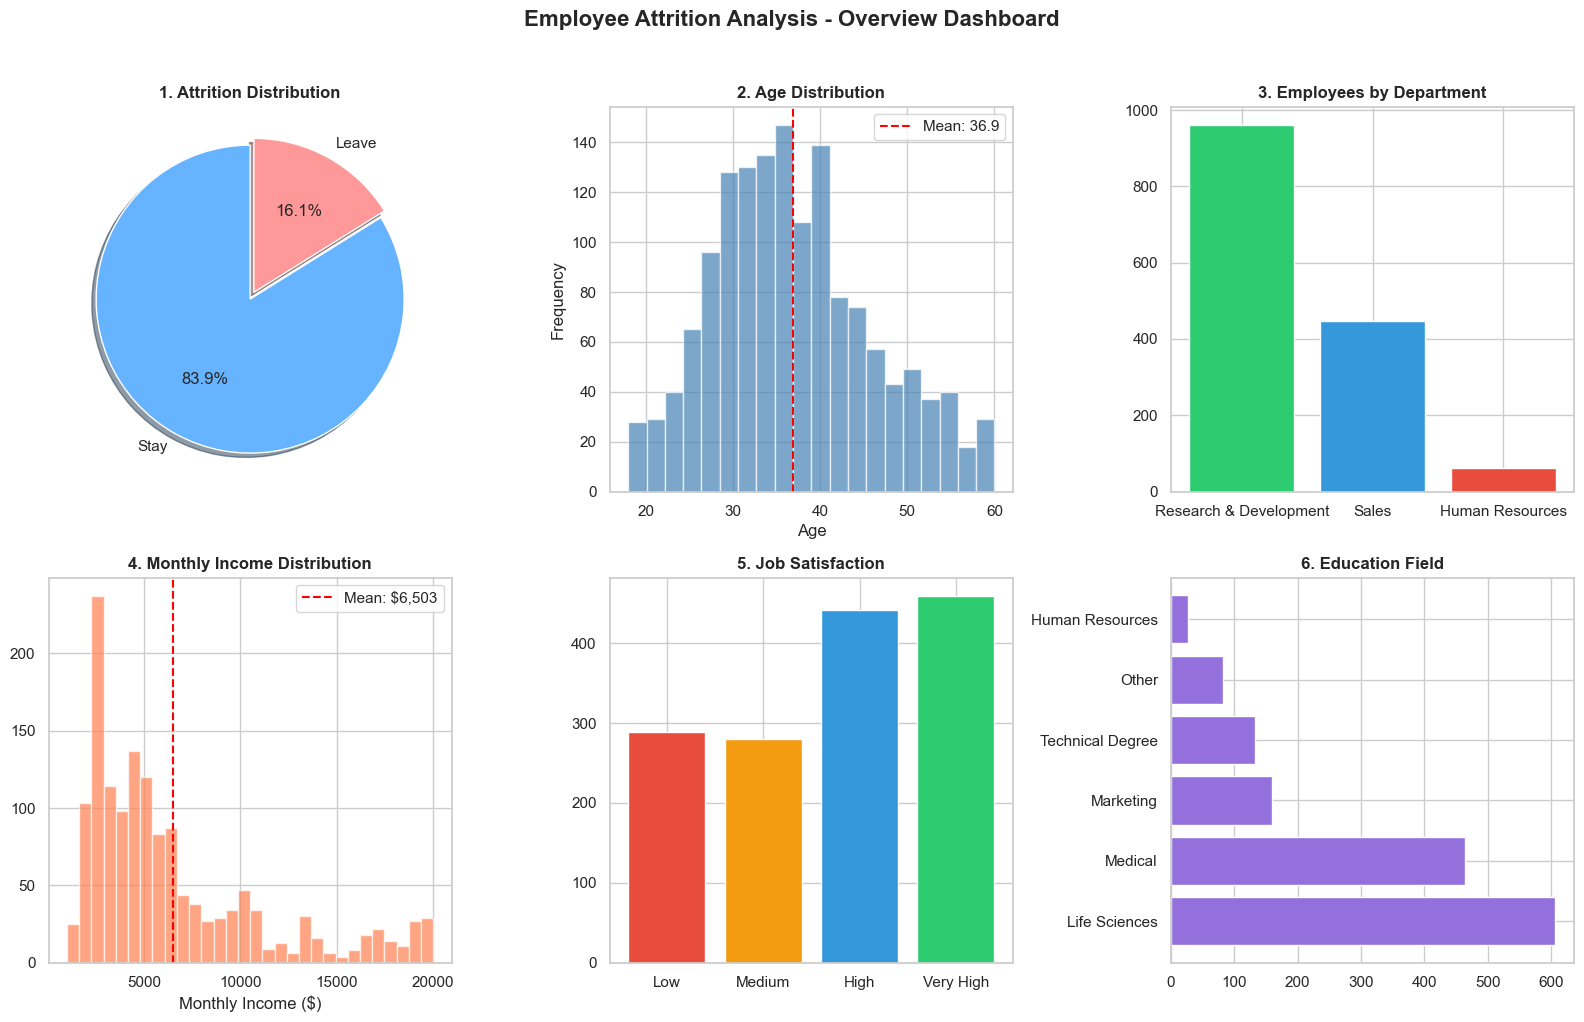


✅ Dashboard tổng quan đã được tạo!


In [18]:
# ============================================================================
# CELL 14: DASHBOARD TỔNG QUAN
# ============================================================================

print("\n" + "="*70)
print("              DASHBOARD TỔNG QUAN")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Employee Attrition Analysis - Overview Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. PIE CHART: ATTRITION
attrition_counts = df['Attrition'].value_counts()
axes[0, 0].pie(attrition_counts.values, labels=['Stay', 'Leave'],
               autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'],
               explode=[0, 0.05], startangle=90, shadow=True)
axes[0, 0].set_title('1. Attrition Distribution', fontweight='bold')

# 2. HISTOGRAM: AGE
axes[0, 1].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 1].axvline(x=df['Age'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 1].set_title('2. Age Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. BAR: DEPARTMENT
dept_counts = df['Department'].value_counts()
axes[0, 2].bar(range(len(dept_counts)), dept_counts.values, 
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 2].set_title('3. Employees by Department', fontweight='bold')
axes[0, 2].set_xticks(range(len(dept_counts)))
axes[0, 2].set_xticklabels(dept_counts.index, rotation=0)

# 4. HISTOGRAM: MONTHLY INCOME
axes[1, 0].hist(df['MonthlyIncome'], bins=30, color='coral', edgecolor='white', alpha=0.7)
axes[1, 0].axvline(x=df['MonthlyIncome'].mean(), color='red', linestyle='--',
                   label=f"Mean: ${df['MonthlyIncome'].mean():,.0f}")
axes[1, 0].set_title('4. Monthly Income Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Monthly Income ($)')
axes[1, 0].legend()

# 5. BAR: JOB SATISFACTION
sat_counts = df['JobSatisfaction'].value_counts().sort_index()
sat_labels = ['Low', 'Medium', 'High', 'Very High']
axes[1, 1].bar(range(4), sat_counts.values, color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
axes[1, 1].set_title('5. Job Satisfaction', fontweight='bold')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(sat_labels)

# 6. BARH: EDUCATION FIELD
edu_counts = df['EducationField'].value_counts()
axes[1, 2].barh(range(len(edu_counts)), edu_counts.values, color='mediumpurple')
axes[1, 2].set_title('6. Education Field', fontweight='bold')
axes[1, 2].set_yticks(range(len(edu_counts)))
axes[1, 2].set_yticklabels(edu_counts.index)

plt.tight_layout()
plt.show()

print("\n✅ Dashboard tổng quan đã được tạo!")


              BIVARIATE ANALYSIS - ATTRITION


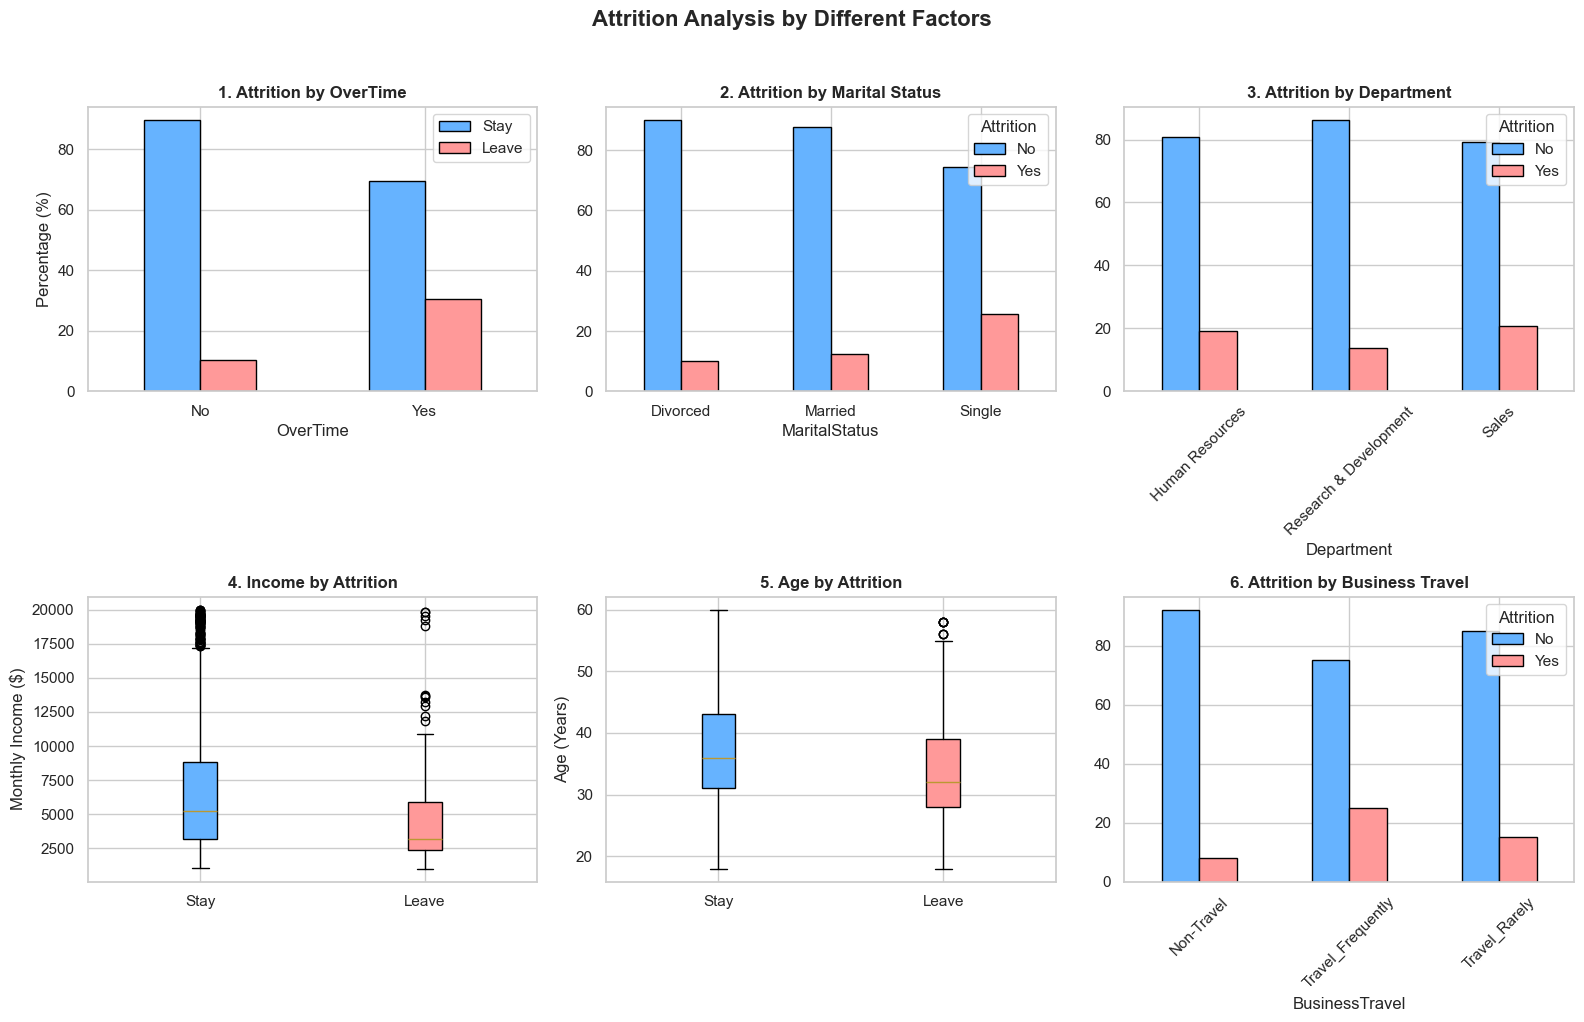


✅ Bivariate analysis đã được tạo!


In [19]:
# ============================================================================
# CELL 15: BIVARIATE ANALYSIS - ATTRITION VS FACTORS
# ============================================================================

print("\n" + "="*70)
print("              BIVARIATE ANALYSIS - ATTRITION")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Attrition Analysis by Different Factors', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. OVERTIME
ot_attr = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ot_attr.plot(kind='bar', ax=axes[0, 0], color=['#66b3ff', '#ff9999'], edgecolor='black')
axes[0, 0].set_title('1. Attrition by OverTime', fontweight='bold')
axes[0, 0].set_xlabel('OverTime')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['Stay', 'Leave'])
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. MARITAL STATUS
ms_attr = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index') * 100
ms_attr.plot(kind='bar', ax=axes[0, 1], color=['#66b3ff', '#ff9999'], edgecolor='black')
axes[0, 1].set_title('2. Attrition by Marital Status', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. DEPARTMENT
dp_attr = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dp_attr.plot(kind='bar', ax=axes[0, 2], color=['#66b3ff', '#ff9999'], edgecolor='black')
axes[0, 2].set_title('3. Attrition by Department', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. BOXPLOT: INCOME BY ATTRITION
income_stay = df[df['Attrition'] == 'No']['MonthlyIncome']
income_leave = df[df['Attrition'] == 'Yes']['MonthlyIncome']
bp = axes[1, 0].boxplot([income_stay, income_leave], labels=['Stay', 'Leave'], patch_artist=True)
bp['boxes'][0].set_facecolor('#66b3ff')
bp['boxes'][1].set_facecolor('#ff9999')
axes[1, 0].set_title('4. Income by Attrition', fontweight='bold')
axes[1, 0].set_ylabel('Monthly Income ($)')

# 5. BOXPLOT: AGE BY ATTRITION
age_stay = df[df['Attrition'] == 'No']['Age']
age_leave = df[df['Attrition'] == 'Yes']['Age']
bp2 = axes[1, 1].boxplot([age_stay, age_leave], labels=['Stay', 'Leave'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#66b3ff')
bp2['boxes'][1].set_facecolor('#ff9999')
axes[1, 1].set_title('5. Age by Attrition', fontweight='bold')
axes[1, 1].set_ylabel('Age (Years)')

# 6. BUSINESS TRAVEL
bt_attr = pd.crosstab(df['BusinessTravel'], df['Attrition'], normalize='index') * 100
bt_attr.plot(kind='bar', ax=axes[1, 2], color=['#66b3ff', '#ff9999'], edgecolor='black')
axes[1, 2].set_title('6. Attrition by Business Travel', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Bivariate analysis đã được tạo!")


              CORRELATION MATRIX HEATMAP


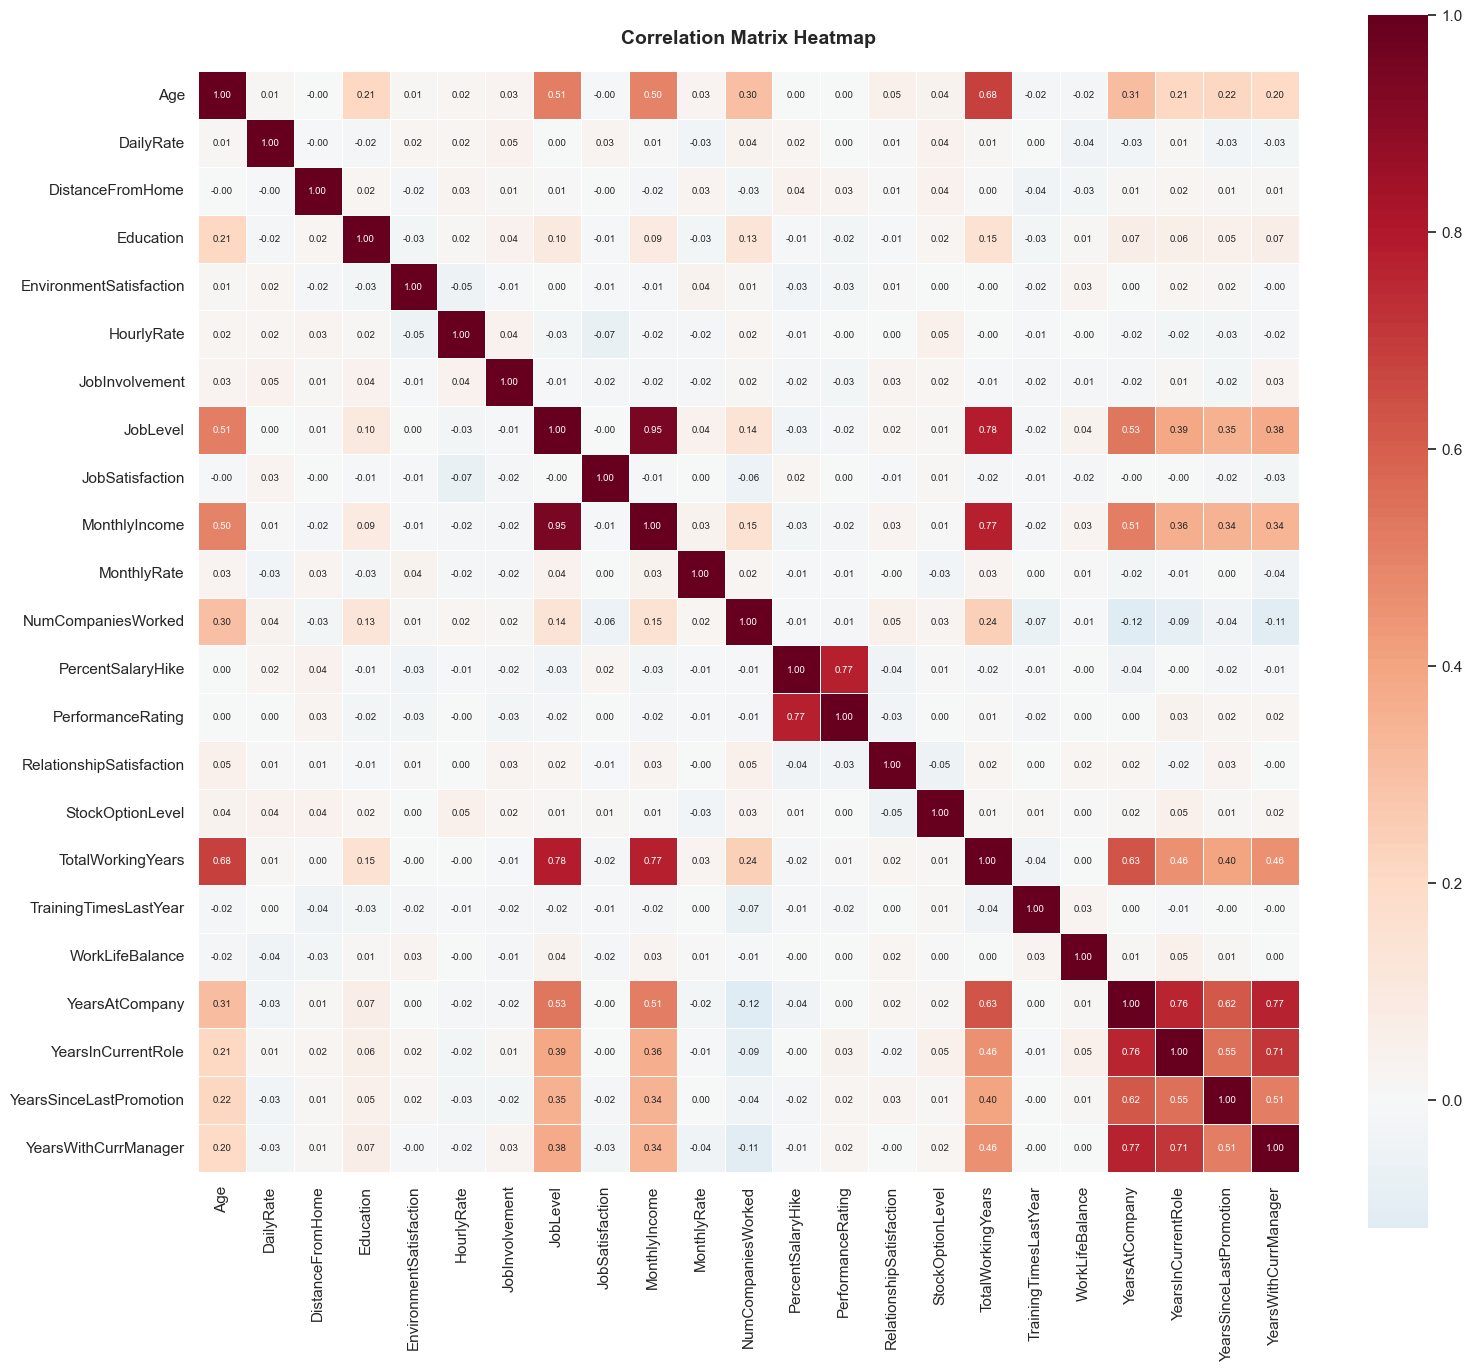


💡 HƯỚNG DẪN ĐỌC HEATMAP:
--------------------------------------------------
   • Màu đỏ đậm: Correlation âm mạnh
   • Màu trắng: Correlation yếu
   • Màu xanh đậm: Correlation dương mạnh


In [20]:
# ============================================================================
# CELL 16: CORRELATION HEATMAP
# ============================================================================

print("\n" + "="*70)
print("              CORRELATION MATRIX HEATMAP")
print("="*70)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_exclude = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 HƯỚNG DẪN ĐỌC HEATMAP:")
print("-"*50)
print("   • Màu đỏ đậm: Correlation âm mạnh")
print("   • Màu trắng: Correlation yếu")
print("   • Màu xanh đậm: Correlation dương mạnh")

In [21]:
# ============================================================================
# CELL 17: TÌM CÁC CẶP BIẾN CÓ CORRELATION CAO
# ============================================================================

print("\n" + "="*70)
print("              CÁC CẶP BIẾN CÓ CORRELATION CAO")
print("="*70)

threshold = 0.6

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        value = upper_triangle.loc[idx, col]
        if pd.notna(value) and abs(value) > threshold:
            high_corr_pairs.append({
                'Variable 1': idx,
                'Variable 2': col,
                'Correlation': round(value, 3),
                'Type': 'Positive' if value > 0 else 'Negative'
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False, key=abs)
    print(f"\n⚠️ Phát hiện {len(high_corr_df)} cặp có |correlation| > {threshold}:\n")
    display(high_corr_df)
    print("\n💡 KHUYẾN NGHỊ: Correlation > 0.8 cần cân nhắc loại bỏ 1 biến")
else:
    print(f"\n✅ Không có cặp nào có |correlation| > {threshold}")


              CÁC CẶP BIẾN CÓ CORRELATION CAO

⚠️ Phát hiện 10 cặp có |correlation| > 0.6:



,Variable 1,Variable 2,Correlation,Type
0,JobLevel,MonthlyIncome,0.9500,Positive
3,JobLevel,TotalWorkingYears,0.7820,Positive
1,PercentSalaryHike,PerformanceRating,0.7740,Positive
4,MonthlyIncome,TotalWorkingYears,0.7730,Positive
8,YearsAtCompany,YearsWithCurrManager,0.7690,Positive
6,YearsAtCompany,YearsInCurrentRole,0.7590,Positive
9,YearsInCurrentRole,YearsWithCurrManager,0.7140,Positive
2,Age,TotalWorkingYears,0.6800,Positive
5,TotalWorkingYears,YearsAtCompany,0.6280,Positive
7,YearsAtCompany,YearsSinceLastPromotion,0.6180,Positive



💡 KHUYẾN NGHỊ: Correlation > 0.8 cần cân nhắc loại bỏ 1 biến


---

# 🔧 PHẦN 7: TIỀN XỬ LÝ DỮ LIỆU

---

## 7.1 Các Bước Tiền Xử Lý

| Bước | Mục đích | Kỹ thuật |
|------|----------|----------|
| 1. Loại bỏ cột | Giảm dimensionality | Drop zero variance, ID |
| 2. Encoding | Chuyển text → số | Label, One-Hot |
| 3. Scaling | Chuẩn hóa scale | Standardization |

---

In [22]:
# ============================================================================
# CELL 18: TẠO BẢN SAO VÀ LOẠI BỎ CỘT KHÔNG CẦN THIẾT
# ============================================================================

print("\n" + "="*70)
print("              TIỀN XỬ LÝ DỮ LIỆU")
print("="*70)

df_processed = df.copy()

print(f"\n📊 BƯỚC 1: LOẠI BỎ CỘT KHÔNG CẦN THIẾT")
print("-"*50)

cols_to_drop = {
    'EmployeeCount': 'Zero variance',
    'StandardHours': 'Zero variance',
    'Over18': 'Zero variance',
    'EmployeeNumber': 'ID column'
}

print(f"   Số cột trước: {df_processed.shape[1]}")

for col, reason in cols_to_drop.items():
    if col in df_processed.columns:
        df_processed = df_processed.drop(columns=[col])
        print(f"   ❌ Loại bỏ: {col} ({reason})")

print(f"\n   Số cột sau: {df_processed.shape[1]}")


              TIỀN XỬ LÝ DỮ LIỆU

📊 BƯỚC 1: LOẠI BỎ CỘT KHÔNG CẦN THIẾT
--------------------------------------------------
   Số cột trước: 35
   ❌ Loại bỏ: EmployeeCount (Zero variance)
   ❌ Loại bỏ: StandardHours (Zero variance)
   ❌ Loại bỏ: Over18 (Zero variance)
   ❌ Loại bỏ: EmployeeNumber (ID column)

   Số cột sau: 31


In [23]:
# ============================================================================
# CELL 19: LABEL ENCODING CHO BIẾN BINARY
# ============================================================================
#
# VÌ SAO dùng Label Encoding cho binary?
# - Đơn giản: Chỉ cần 1 cột (0 hoặc 1)
# - Không tăng dimensionality
#
# ============================================================================

print(f"\n📊 BƯỚC 2: LABEL ENCODING CHO BIẾN BINARY")
print("-"*50)

# Mã hóa Attrition
df_processed['Attrition_Encoded'] = (df_processed['Attrition'] == 'Yes').astype(int)
print("   ✅ Attrition: Yes → 1, No → 0")

# Mã hóa Gender
df_processed['Gender_Encoded'] = (df_processed['Gender'] == 'Male').astype(int)
print("   ✅ Gender: Male → 1, Female → 0")

# Mã hóa OverTime
df_processed['OverTime_Encoded'] = (df_processed['OverTime'] == 'Yes').astype(int)
print("   ✅ OverTime: Yes → 1, No → 0")

print("\n   Kiểm tra:")
display(df_processed[['Attrition', 'Attrition_Encoded', 
                      'Gender', 'Gender_Encoded']].head(3))


📊 BƯỚC 2: LABEL ENCODING CHO BIẾN BINARY
--------------------------------------------------
   ✅ Attrition: Yes → 1, No → 0
   ✅ Gender: Male → 1, Female → 0
   ✅ OverTime: Yes → 1, No → 0

   Kiểm tra:


,Attrition,Attrition_Encoded,Gender,Gender_Encoded
0,Yes,1,Female,0
1,No,0,Male,1
2,Yes,1,Male,1


In [24]:
# ============================================================================
# CELL 20: ONE-HOT ENCODING CHO BIẾN NOMINAL
# ============================================================================
#
# VÌ SAO dùng One-Hot cho nominal?
# - Không có thứ tự giữa categories
# - Label Encoding sẽ tạo quan hệ thứ tự giả
#
# ============================================================================

print(f"\n📊 BƯỚC 3: ONE-HOT ENCODING CHO BIẾN NOMINAL")
print("-"*50)

nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus', 'BusinessTravel']

print(f"   Số cột trước: {df_processed.shape[1]}")

for col in nominal_cols:
    if col in df_processed.columns:
        dummies = pd.get_dummies(df_processed[col], prefix=col, drop_first=True)
        df_processed = pd.concat([df_processed, dummies], axis=1)
        print(f"   ✅ {col}: +{len(dummies.columns)} dummy columns")

print(f"\n   Số cột sau: {df_processed.shape[1]}")


📊 BƯỚC 3: ONE-HOT ENCODING CHO BIẾN NOMINAL
--------------------------------------------------
   Số cột trước: 34
   ✅ Department: +2 dummy columns
   ✅ EducationField: +5 dummy columns
   ✅ JobRole: +8 dummy columns
   ✅ MaritalStatus: +2 dummy columns
   ✅ BusinessTravel: +2 dummy columns

   Số cột sau: 53


In [25]:
# ============================================================================
# CELL 21: STANDARDIZATION (Z-SCORE)
# ============================================================================
#
# VÌ SAO cần chuẩn hóa?
# - Các biến có scale khác nhau
# - Một số algorithms nhạy cảm với scale
# - Gradient Descent hội tụ nhanh hơn
#
# Công thức: z = (x - mean) / std
#
# ============================================================================

print(f"\n📊 BƯỚC 4: STANDARDIZATION (Z-SCORE)")
print("-"*50)
print("   Công thức: z = (x - mean) / std")
print("   Kết quả: Mean = 0, Std = 1\n")

cols_to_standardize = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                       'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                       'YearsWithCurrManager']

for col in cols_to_standardize:
    if col in df_processed.columns:
        col_mean = df_processed[col].mean()
        col_std = df_processed[col].std()
        if col_std != 0:
            df_processed[f'{col}_Scaled'] = (df_processed[col] - col_mean) / col_std

print(f"   ✅ Đã chuẩn hóa {len(cols_to_standardize)} cột")

# Kiểm tra
print("\n   Kiểm tra (Age):")
print(f"      Original - Mean: {df_processed['Age'].mean():.2f}, Std: {df_processed['Age'].std():.2f}")
print(f"      Scaled   - Mean: {df_processed['Age_Scaled'].mean():.4f}, Std: {df_processed['Age_Scaled'].std():.4f}")


📊 BƯỚC 4: STANDARDIZATION (Z-SCORE)
--------------------------------------------------
   Công thức: z = (x - mean) / std
   Kết quả: Mean = 0, Std = 1

   ✅ Đã chuẩn hóa 14 cột

   Kiểm tra (Age):
      Original - Mean: 36.92, Std: 9.14
      Scaled   - Mean: -0.0000, Std: 1.0000


In [26]:
# ============================================================================
# CELL 22: TÓM TẮT KẾT QUẢ
# ============================================================================

print("\n" + "="*70)
print("              TÓM TẮT KẾT QUẢ SAU TIỀN XỬ LÝ")
print("="*70)

print(f"\n📊 THÔNG TIN DATASET:")
print("-"*50)
print(f"   • Số dòng: {df_processed.shape[0]:,}")
print(f"   • Số cột ban đầu: {df.shape[1]}")
print(f"   • Số cột sau xử lý: {df_processed.shape[1]}")

print("\n" + "="*70)
print("✅ TIỀN XỬ LÝ DỮ LIỆU HOÀN TẤT!")
print("="*70)


              TÓM TẮT KẾT QUẢ SAU TIỀN XỬ LÝ

📊 THÔNG TIN DATASET:
--------------------------------------------------
   • Số dòng: 1,470
   • Số cột ban đầu: 35
   • Số cột sau xử lý: 67

✅ TIỀN XỬ LÝ DỮ LIỆU HOÀN TẤT!


In [27]:
# ============================================================================
# CELL 23: LƯU DỮ LIỆU
# ============================================================================

print("\n" + "="*70)
print("              LƯU DỮ LIỆU")
print("="*70)

output_file = 'Employee_Attrition_Processed.csv'
df_processed.to_csv(output_file, index=False)

print(f"\n✅ Đã lưu file: {output_file}")
print(f"   • Kích thước: {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")


              LƯU DỮ LIỆU

✅ Đã lưu file: Employee_Attrition_Processed.csv
   • Kích thước: 1,470 rows × 67 columns


---

# 📝 PHẦN 8: TÓM TẮT VÀ KẾT LUẬN

---

## 8.1 Những Gì Đã Học

| Bước | Nội dung | Kỹ thuật |
|------|----------|----------|
| 1 | Thiết lập môi trường | Import, configure |
| 2 | Tải dữ liệu | pd.read_csv() |
| 3 | Khám phá ban đầu | .info(), .head(), .describe() |
| 4 | Kiểm tra chất lượng | Missing, duplicates, zero variance |
| 5 | Phát hiện Outliers | IQR, Z-score |
| 6 | Trực quan hóa | Matplotlib, Seaborn |
| 7 | Tiền xử lý | Encoding, Scaling |

---

## 8.2 Key Insights

**Về Dataset:**
- 1,470 nhân viên với 35 đặc trưng
- Không có missing values
- 3 cột zero variance cần loại bỏ

**Về Attrition:**
- Tỷ lệ nghỉ việc: ~16%
- Class imbalance: ~5:1

**Các yếu tố rủi ro cao:**
- OverTime = Yes
- Marital Status = Single
- Thu nhập thấp
- Travel_Frequently

---

## 8.3 Bước Tiếp Theo

- **Session 2**: Linear Regression từ đầu
- **Session 3**: Ridge, Lasso, Elastic Net
- **Session 4**: Classification (KNN, Naive Bayes)

---

## 8.4 Tài Liệu Tham Khảo

**Medium:**
- [EDA Using Python](https://medium.com/@siddhardhan23/exploratory-data-analysis-25b7c0f0bfec)
- [Complete Guide to Data Cleaning](https://medium.com/bitgrit-data-science-publication/complete-guide-to-data-cleaning-with-python-9c06da8c09c7)

**Documentation:**
- [Pandas](https://pandas.pydata.org/docs/)
- [Seaborn](https://seaborn.pydata.org/tutorial.html)

---

*Tài liệu được tạo cho lớp DT2408L/AT2408L-ON - APTECH Computer Education*  
*Cập nhật: Tháng 01/2026*